In this lesson we will learn how to find a rogue wave solution of an ODE via a neural network model

The ODE of interests is a Duffin system

u'' = u - u^3

Soliton solution is u(x) = A sech(B(x-C))

(it has freedom to scale customizable height, width, and also location)

### 1. Create the set of input data

Let us generate x randomly between -L to +L, with L=5

Then divide it into |x| < L/10 and the rest, i.e. x_in and x_out

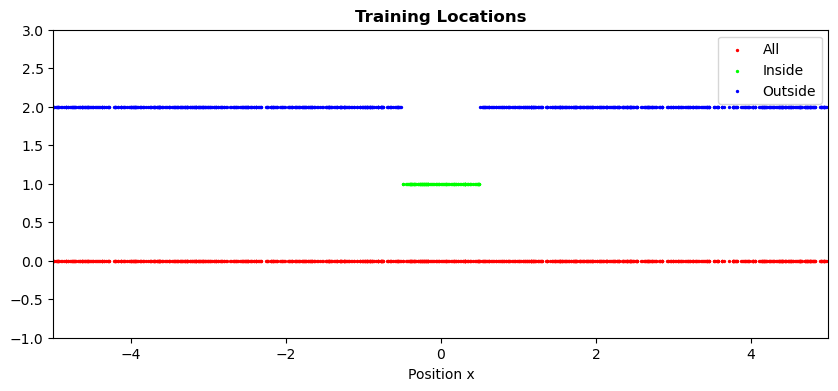

((108,), (892,))

In [1]:
import numpy as np
import pylab as pl
import math as m

n_data = 10**3
L  =  5.0

np.random.seed(37)
x_all = np.random.uniform(-L, +L, size=n_data)

# Split: |x| < L/10  vs the rest
mask_in = np.abs(x_all) < (L/10)

x_in  = x_all[mask_in]
x_out = x_all[~mask_in]

f = pl.figure(figsize=(10,4))
sf_1 = f.add_subplot(1,1,1)
    
sf_1.scatter(x_all,0*x_all, s=2, color=(1,0,0), alpha=1.0, label='All')
sf_1.scatter(x_in,0*x_in+1, s=2, color=(0,1,0), alpha=1.0, label='Inside')
sf_1.scatter(x_out,0*x_out+2, s=2, color=(0,0,1), alpha=1.0, label='Outside')
sf_1.set_title('Training Locations', fontweight='bold')
sf_1.set_xlabel('Position x')
sf_1.axis([-L,+L,-1,+3])
sf_1.legend()

pl.show()

x_in.shape, x_out.shape

Now let us preparing them for training

In [2]:
# Now make them Torch tensor
import torch
x_all_Input = torch.tensor(x_all, dtype=torch.float32).unsqueeze(1)
x_in_Input = torch.tensor(x_in, dtype=torch.float32).unsqueeze(1)
x_out_Input = torch.tensor(x_out, dtype=torch.float32).unsqueeze(1)

x_all_Input.shape, x_in_Input.shape, x_out_Input.shape

(torch.Size([1000, 1]), torch.Size([108, 1]), torch.Size([892, 1]))

### 2. Create a Perceptron (Neural Network)

Let us create a neural network of 1 hidden neural layers, 32 neurons each. 

There is one input and one output! It's just a single-variable function!

In [3]:
import torch.nn as nn

# Set seeds for reproducibility
torch.manual_seed(42)

# Set device to CPU
device = torch.device('cpu')

# Create the Encoder

class Network(nn.Module):
    
    def __init__(self):
        super(Network, self).__init__()
        
        self.fc1 = nn.Linear(1, 32) 
        #self.fc2 = nn.Linear(32, 32) 
        self.fc3 = nn.Linear(32, 1)  
        self.activation = nn.Tanh()

    def forward(self,x):
        x = self.activation(self.fc1(x))  
        #x = self.activation(self.fc2(x))  
        x = self.fc3(x) 
        return x
    
u_NN = Network().to(device)

u_NN

Network(
  (fc1): Linear(in_features=1, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (activation): Tanh()
)

Add A and B as trainable parameters

In [4]:
# --- learnable scalars (raw -> positive via softplus) ---
A_raw = nn.Parameter(torch.tensor(1.0))   # initialize however you want
B_raw = nn.Parameter(torch.tensor(1.0))

def A_B():
    A = F.softplus(A_raw) + 1e-6
    B = F.softplus(B_raw) + 1e-6
    return A, B

We now need to define the gradient operator and then the customized loss function

In [5]:
# Autodiff helpers
def gradients(y, x):
    # dy/dx for scalar y and vector x
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y),
                               retain_graph=True, create_graph=True)[0]

u_peak = 1.0
# Set u(0)=u_peak
def center_peak_residual():
    x0 = torch.tensor([0.0], dtype=torch.float32).unsqueeze(1)
    return u_NN(x0)-u_peak

# Set u'(0)=0
def flat_peak_residual():
    x0 = torch.tensor([0.0], dtype=torch.float32).unsqueeze(1)
    x0.requires_grad_(True)
    u = u_NN(x0)
    # first derivative du/dx
    dudx = gradients(u,x0)
    return dudx

# Set u(+/-L/10)=u_peak/3
def edge_peak_residual():
    xe = torch.tensor([-L/10,+L/10], dtype=torch.float32).unsqueeze(1)
    return u_NN(xe)-u_peak/3

# Set |u(x)|<u_peak/3 by consider a residual (|u(x)|-u_peak)^2 
import torch.nn.functional as F
def outside_bound_residual(xo):
    u = u_NN(xo)
    """
    u: tensor of u(x) values (any shape)
    Penalizes violations of |u| <= u_peak/3.
    """
    violation = F.relu(torch.abs(u) - u_peak/3)  # zero if satisfied
    return violation

# Compute ODE residual r = ddu/dxdx - (u-u^3) at inside points
def ode_residual(x):
    # X needs gradients
    x.requires_grad_(True)
    u = u_NN(x)
    # first derivative du/dx
    dudx = gradients(u,x)
    # second derivative ddu/dxdx
    ddudxdx = gradients(dudx,x)
    # Load parameters
    A, B = A_B()
    return ddudxdx - (A*u-B*u**3)

### 3. Train the Neural Network

Now let us do the training, with the loss weight (c1,c2,c3,c4)=(1,1,1,1)

In [6]:
n_epochs = 5*10**5
learning_rate = 1e-4
n_rep = 5*10**3

params = list(u_NN.parameters()) + [A_raw, B_raw]
optimizer = torch.optim.Adam(params, lr=learning_rate)

mse = nn.MSELoss()

Epoch_List = np.arange(n_epochs)+1
Train_Loss_List = np.zeros((n_epochs))
Train_L1_List = np.zeros((n_epochs))
Train_L2_List = np.zeros((n_epochs))
Train_L3_List = np.zeros((n_epochs))
Train_L4_List = np.zeros((n_epochs))
Train_L5_List = np.zeros((n_epochs))
c1, c2, c3, c4, c5 = 1, 1, 1, 1, 10

for ep in range(n_epochs): 
    u_NN.train()
    optimizer.zero_grad()

    # L1 is set peak value
    r1 = center_peak_residual()
    L1 = mse(r1, torch.zeros_like(r1))

    # L2 is set peak flat
    r2 = flat_peak_residual()
    L2 = mse(r2, torch.zeros_like(r2))

    # L3 is set edges
    r3 = edge_peak_residual()
    L3 = mse(r3, torch.zeros_like(r3))

    # L4 is set outside bound
    r4 = outside_bound_residual(x_out_Input)
    L4 = mse(r4, torch.zeros_like(r4))
    
    # L5 is set ODE
    r5 = ode_residual(x_all_Input)
    L5 = mse(r5, torch.zeros_like(r5))

    # Get total loss
    loss = c1*L1 + c2*L2 + c3*L3 + c4*L4 + c5*L5
    loss.backward()
    optimizer.step()

    Train_Loss_List[ep] = loss.item()   # no .data
    Train_L1_List[ep]   = L1.item()
    Train_L2_List[ep]   = L2.item()
    Train_L3_List[ep]   = L3.item()
    Train_L4_List[ep]   = L4.item()
    Train_L5_List[ep]   = L5.item()

    if (ep) % n_rep == 0:
        print(f"Epoch {ep+1}\tTraining Loss: {Train_Loss_List[ep]}")

Epoch 1	Training Loss: 4.610633850097656
Epoch 5001	Training Loss: 0.860467791557312
Epoch 10001	Training Loss: 0.324940949678421
Epoch 15001	Training Loss: 0.21499857306480408
Epoch 20001	Training Loss: 0.19787411391735077
Epoch 25001	Training Loss: 0.1905006766319275
Epoch 30001	Training Loss: 0.18206621706485748
Epoch 35001	Training Loss: 0.17354601621627808
Epoch 40001	Training Loss: 0.1648218184709549
Epoch 45001	Training Loss: 0.1559218466281891
Epoch 50001	Training Loss: 0.14689901471138
Epoch 55001	Training Loss: 0.13778336346149445
Epoch 60001	Training Loss: 0.12864667177200317
Epoch 65001	Training Loss: 0.11958426237106323
Epoch 70001	Training Loss: 0.11066310107707977
Epoch 75001	Training Loss: 0.10198892652988434
Epoch 80001	Training Loss: 0.09362020343542099
Epoch 85001	Training Loss: 0.08560557663440704
Epoch 90001	Training Loss: 0.07802759110927582
Epoch 95001	Training Loss: 0.07091362029314041
Epoch 100001	Training Loss: 0.0642545223236084
Epoch 105001	Training Loss: 0.

Let us now see how the loss function changes with training epochs

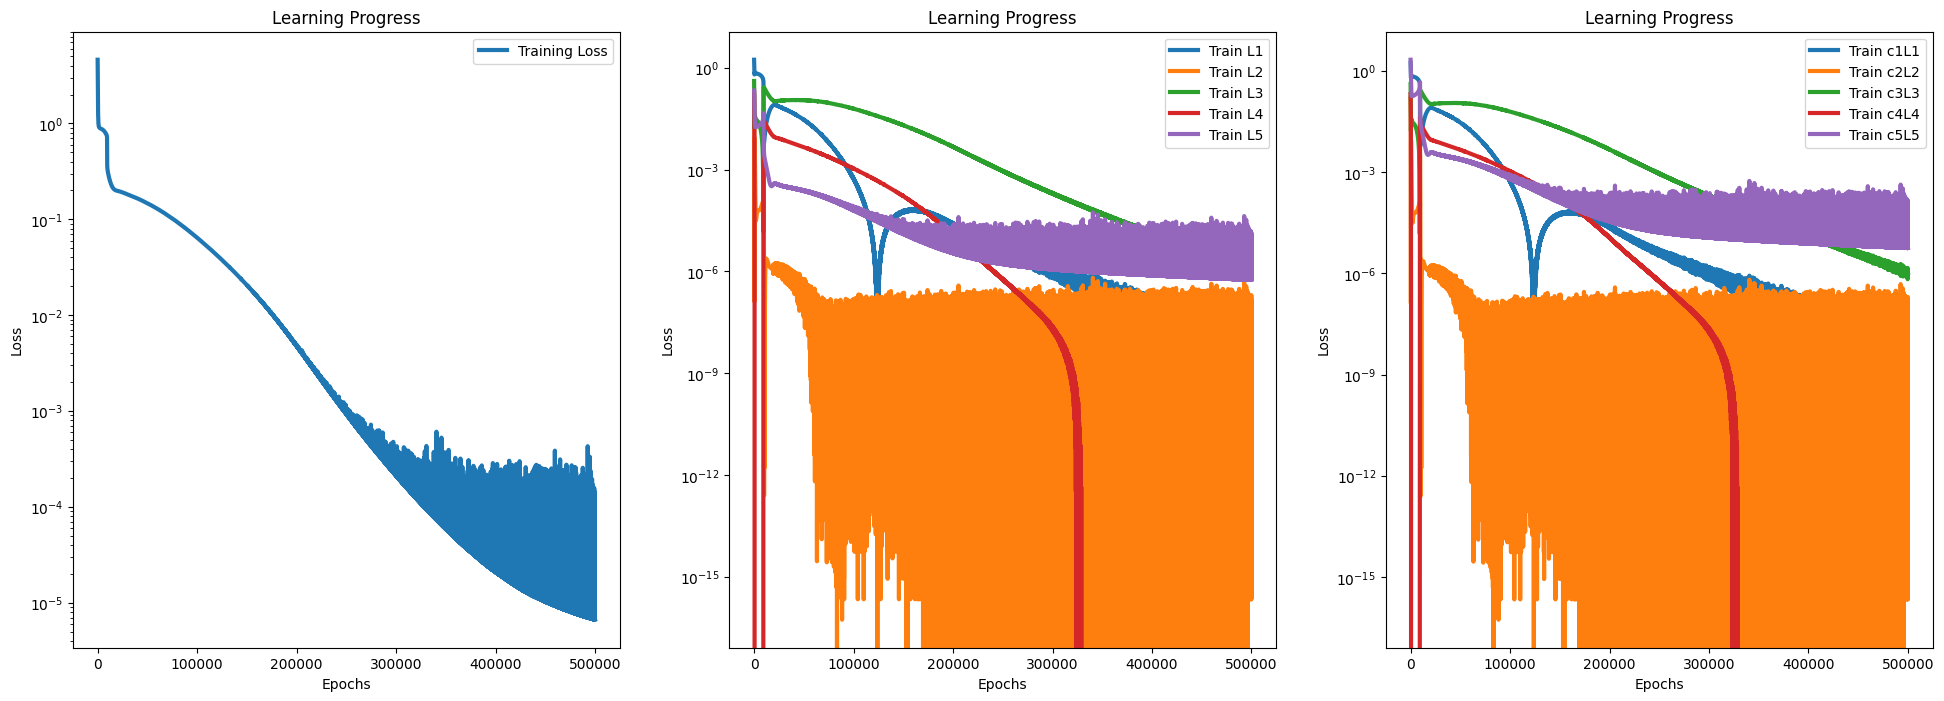

In [7]:
import pylab as pl

f1 = pl.figure(figsize=(24,8))
sf1_1, sf1_2, sf1_3 = f1.add_subplot(1,3,1), f1.add_subplot(1,3,2), f1.add_subplot(1,3,3)

sf1_1.plot(Epoch_List,Train_Loss_List, linewidth=3, label='Training Loss')

sf1_1.set_title('Learning Progress')
sf1_1.set_xlabel('Epochs')
sf1_1.set_ylabel('Loss')
sf1_1.set_yscale('log')
sf1_1.legend()

sf1_2.plot(Epoch_List,Train_L1_List, linewidth=3, label='Train L1')
sf1_2.plot(Epoch_List,Train_L2_List, linewidth=3, label='Train L2')
sf1_2.plot(Epoch_List,Train_L3_List, linewidth=3, label='Train L3')
sf1_2.plot(Epoch_List,Train_L4_List, linewidth=3, label='Train L4')
sf1_2.plot(Epoch_List,Train_L5_List, linewidth=3, label='Train L5')
sf1_2.set_title('Learning Progress')
sf1_2.set_xlabel('Epochs')
sf1_2.set_ylabel('Loss')
sf1_2.set_yscale('log')
sf1_2.legend()

sf1_3.plot(Epoch_List,c1*Train_L1_List, linewidth=3, label='Train c1L1')
sf1_3.plot(Epoch_List,c2*Train_L2_List, linewidth=3, label='Train c2L2')
sf1_3.plot(Epoch_List,c3*Train_L3_List, linewidth=3, label='Train c3L3')
sf1_3.plot(Epoch_List,c4*Train_L4_List, linewidth=3, label='Train c4L4')
sf1_3.plot(Epoch_List,c5*Train_L5_List, linewidth=3, label='Train c5L5')
sf1_3.set_title('Learning Progress')
sf1_3.set_xlabel('Epochs')
sf1_3.set_ylabel('Loss')
sf1_3.set_yscale('log')
sf1_3.legend()

pl.show()

What has been learnt by this neural network?

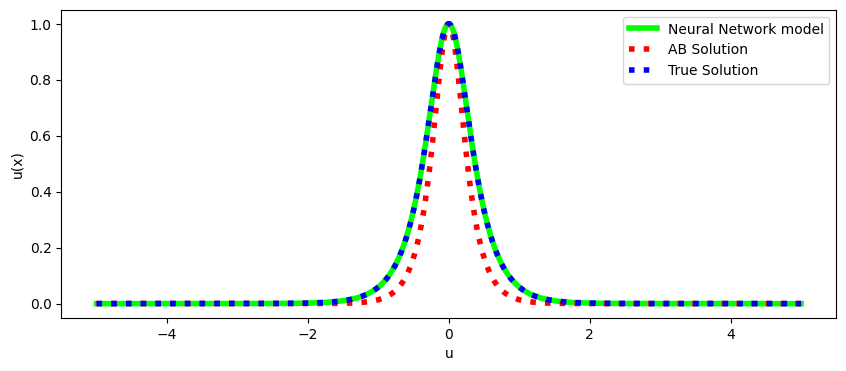

In [8]:
## Plot the Learnt
n_val = 10**4
x_test_Input = torch.linspace(-L, +L, steps=n_val).unsqueeze(1)
x_test = x_test_Input.detach().numpy()
u_test = u_NN(x_test_Input).detach().numpy()

A_val, B_val = A_B()
A_val = A_val.detach().numpy()   
B_val = B_val.detach().numpy()

u_withAB = np.sqrt(2*A_val/B_val)/np.cosh(np.sqrt(B_val)*x_test)

w = np.arccosh(3)/(L/10)
u_shouldbe = u_peak/np.cosh(w*x_test)

f2 = pl.figure(figsize=(10,4))
sf2_1 = f2.add_subplot(1,1,1)

sf2_1.plot(x_test, u_test, linestyle='-', color=(0,1,0), linewidth=4, label='Neural Network model')
sf2_1.plot(x_test, u_withAB, linestyle=':', color=(1,0,0), linewidth=4, label='AB Solution')
sf2_1.plot(x_test, u_shouldbe, linestyle=':', color=(0,0,1), linewidth=4, label='True Solution')
sf2_1.set_xlabel('u')
sf2_1.set_ylabel('u(x)')
sf2_1.legend()

pl.show()

In [9]:
A_val, B_val

(array(12.384267, dtype=float32), array(24.766699, dtype=float32))